# 02_Diffraction_Sorting_SSA_v5 - back to changes on V2

trial to integrate FEP subtraction before nth pixel intensity bar chart for more effective diffraction sorting 

05.01.25 : An intensity-variance metric was combined with a high-intensitypixel heuristic previously validated for Kapton-based measurements, improving robustness for FEP tubing experiments - upgrade to the nth most intense pixel for the FEP Data


this works but still having the issue in that hybrid intensity mapping is off - sowing backgrounds have diffraction and samples with diffraction as backgrounds 

06.01.25 - new more robust file loader trialled 

In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
import h5py
import fabio
import pyFAI
from pyFAI.integrator.azimuthal import AzimuthalIntegrator
import shutil



In [2]:
data_folder = "D:/I11 Beamtime July 25 - LHIST/sorting_v2_test"  # raw 2D files
poni_file = "D:/I11 Beamtime July 25 - LHIST/sorting_v2_test/Calib/calib_fep.poni"
fep_background_file = "D:/I11 Beamtime July 25 - LHIST/sorting_v2_test/Calib/FEP_background_subtraction.xye"

# Output folders
output_root = os.path.join(data_folder, "02_output")
diff_folder = os.path.join(output_root, "diffraction")
bg_folder = os.path.join(output_root, "background")

os.makedirs(diff_folder, exist_ok=True)
os.makedirs(bg_folder, exist_ok=True)

print("Folders created:")
print(f"  Diffraction: {diff_folder}")
print(f"  Background: {bg_folder}")


Folders created:
  Diffraction: D:/I11 Beamtime July 25 - LHIST/sorting_v2_test\02_output\diffraction
  Background: D:/I11 Beamtime July 25 - LHIST/sorting_v2_test\02_output\background


In [3]:
fep_q, fep_I = np.loadtxt(fep_background_file, unpack=True)
print("FEP background loaded with", len(fep_q), "points.")



FEP background loaded with 4000 points.


In [4]:
#create pyFAI integrator

ai = AzimuthalIntegrator()
ai.load(poni_file)
print("Calibration loaded:", ai)


Calibration loaded: Detector Detector	 PixelSize= 148µm, 148µm	 BottomRight (3)
Wavelength= 4.959368e-11 m
SampleDetDist= 4.356211e-01 m	PONI= 2.130872e-01, 2.147040e-01 m	rot1=0.000680  rot2=-0.001143  rot3=0.000000 rad
DirectBeamDist= 435.621 mm	Center: x=1448.702, y=1436.414 pix	Tilt= 0.076° tiltPlanRotation= -120.743° 𝛌= 0.496Å


In [5]:
# Load Raw Files (FIXED for Pixium / NeXus)
# changed from origional diffraction sorting script

def load_detector_frame(filepath):
    """
    Load detector image from I11 Pixium NeXus, HDF5, or standard formats.
    Always returns a 2D numpy array.
    """
    ext = filepath.lower()

    try:
        if ext.endswith((".hdf", ".h5", ".nxs")):
            with h5py.File(filepath, "r") as f:

                # ✅ Explicit known Pixium paths (ORDER MATTERS)
                known_paths = [
                    "entry/data/data",                 # <-- YOUR FILES
                    "entry1/data/data",
                    "entry1/Pixium10:detector/data",
                    "entry/Pixium10:detector/data",
                    "entry1/detector/data",
                    "entry/detector/data",
                ]

                for path in known_paths:
                    if path in f:
                        data = f[path][()]
                        if data.ndim == 3:
                            return data[0]
                        elif data.ndim == 2:
                            return data

                # 🔁 Fallback: search ANY 2D/3D dataset
                candidate = None

                def find_dataset(name, obj):
                    nonlocal candidate
                    if isinstance(obj, h5py.Dataset):
                        if obj.ndim == 2:
                            candidate = obj[()]
                            raise StopIteration
                        elif obj.ndim == 3 and candidate is None:
                            candidate = obj[0]

                try:
                    f.visititems(find_dataset)
                except StopIteration:
                    pass

                if candidate is not None:
                    return candidate

                raise ValueError("No suitable detector dataset found")

        elif ext.endswith((".tif", ".tiff", ".cbf")):
            return fabio.open(filepath).data

        else:
            raise ValueError(f"Unsupported file type: {filepath}")

    except Exception as e:
        raise RuntimeError(f"Failed to load {filepath}: {e}")



In [6]:
# Cell 6 - 2d aware hybrid score 

def hybrid_diffraction_score_2d(img):
    """
    2D-aware diffraction metric:
    - Computes radial mean and variance to detect rings/arcs
    - Favors structured diffraction over flat background
    """
    if img is None:
        return 0.0

    img = np.nan_to_num(img, nan=0.0)
    img[img < 0] = 0

    # Compute center of detector
    cy, cx = np.array(img.shape) // 2
    y, x = np.indices(img.shape)
    r = np.sqrt((x - cx)**2 + (y - cy)**2)
    r = r.astype(np.int32)

    # Radial mean & variance
    max_radius = np.max(r)
    radial_mean = np.bincount(r.ravel(), weights=img.ravel(), minlength=max_radius+1)
    radial_count = np.bincount(r.ravel(), minlength=max_radius+1)
    radial_mean = radial_mean / np.maximum(radial_count, 1)
    radial_variance = np.bincount(r.ravel(), weights=(img.ravel() - radial_mean[r.ravel()])**2, minlength=max_radius+1)
    radial_variance /= np.maximum(radial_count, 1)

    # Score is sum of radial variance (higher = more rings/arcs)
    score = np.sum(radial_variance)
    return score



In [7]:
def integrate_and_score(img):
    """
    1D pyFAI integration with FEP subtraction.
    Returns: q, I_sub, integrated_strength
    """
    q, I = ai.integrate1d(img, npt=len(fep_q), unit="q_A^-1")
    fep_interp = np.interp(q, fep_q, fep_I)
    I_sub = I - fep_interp
    I_sub[I_sub < 0] = 0
    integrated_strength = np.sum(I_sub)
    return q, I_sub, integrated_strength


In [8]:
import glob
files = sorted(glob.glob(os.path.join(data_folder, "*.hdf")))
print(f"Found {len(files)} .hdf files")


Found 31 .hdf files


In [9]:
scores_2d = []
scores_1d = []
valid_files = []

for f in tqdm(files, desc="Processing frames"):
    img = load_detector_frame(f)
    
    # Stage 1: 2D diffraction presence
    pre_score = hybrid_diffraction_score_2d(img)
    scores_2d.append(pre_score)
    
    if pre_score <= 0:
        continue
    
    # Stage 2: Integration / FEP-subtracted diffraction strength
    q, I_sub, integrated_strength = integrate_and_score(img)
    scores_1d.append(integrated_strength)
    valid_files.append((f, pre_score, integrated_strength))


Processing frames: 100%|███████████████████████████████████████████████████████████████| 31/31 [00:32<00:00,  1.04s/it]


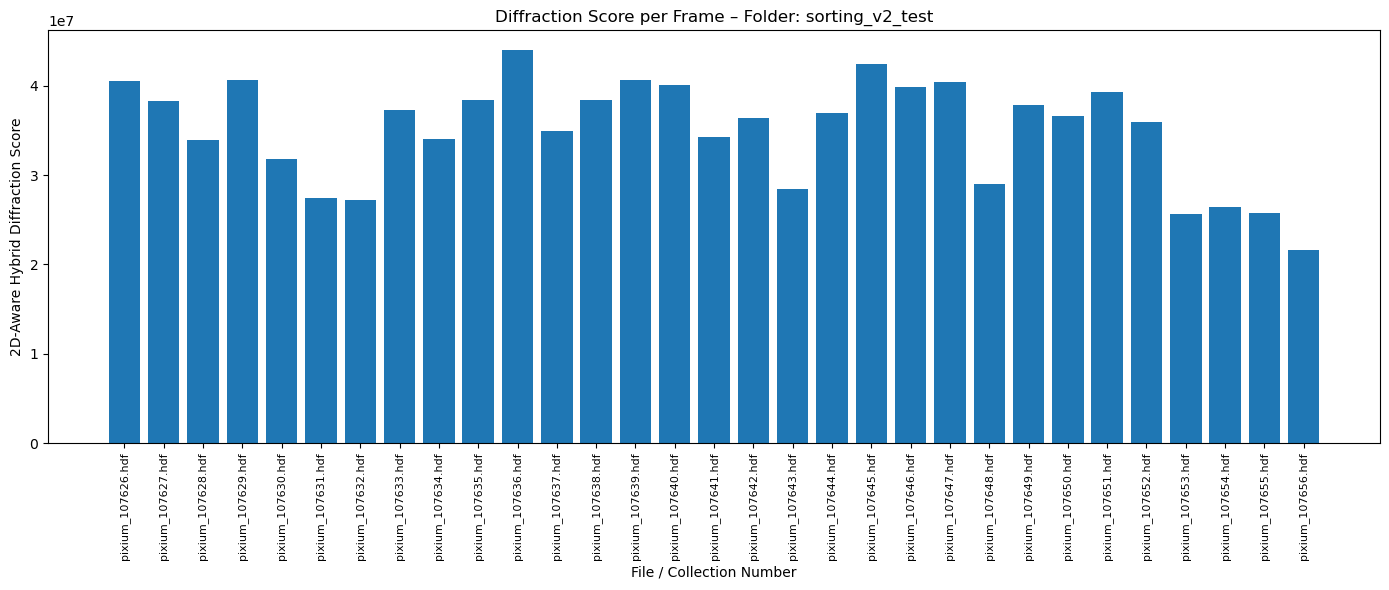

In [10]:
folder_name = os.path.basename(data_folder)
file_labels = [os.path.basename(f) for f in files]

plt.figure(figsize=(14,6))
plt.bar(range(len(scores_2d)), scores_2d)
plt.xlabel("File / Collection Number")
plt.ylabel("2D-Aware Hybrid Diffraction Score")
plt.title(f"Diffraction Score per Frame – Folder: {folder_name}")
plt.xticks(range(len(file_labels)), file_labels, rotation=90, fontsize=8)
plt.tight_layout()
plt.show()



In [ ]:
threshold = float(input("Enter diffraction threshold: "))
print("\nUsing threshold:", threshold)


In [ ]:
for f, score, _ in valid_files:
    dest = diff_folder if score >= threshold else bg_folder
    shutil.copy(f, dest)

print("\nSorting complete.")
print(f"{len([x for x in valid_files if x[1] >= threshold])} diffraction frames")
print(f"{len([x for x in valid_files if x[1] < threshold])} background frames")
